# rredlist Teaching Notebook (All-in-One)

This notebook is designed for teaching and self-learning.
It covers setup, secure API key handling, and practical examples for each main `rredlist` function group.

## 0) Learning outcomes

By the end of this notebook, learners can:
- Configure `rredlist` with their own IUCN API key safely.
- Run baseline and practical examples across all major function groups.
- Inspect outputs and extract reusable fields.
- Produce citation-ready outputs for reporting and teaching.

## 1) Install and load packages

Run once per environment.

In [1]:
# Install once if needed (recommended stable release)
# install.packages("rredlist")
# install.packages("ggplot2")

# Optional alternatives:
# install.packages("remotes")
# remotes::install_github("ropensci/rredlist")
# install.packages("rredlist", repos = "https://ropensci.r-universe.dev/")

library(rredlist)
library(ggplot2)


Warning message:
“package ‘rredlist’ was built under R version 4.5.2”


Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”


## 2) Secure API key setup (do not hard-code keys)

Use one of these safe options:
1. Recommended: `rredlist::rl_use_iucn()`
2. Environment variable `IUCN_REDLIST_KEY`
3. Local `.Renviron` or local `.env` (never committed)

This notebook uses a safe loader that never stores a key in notebook cells.

In [ ]:
# Safe key loader for teaching/shared notebooks.
# Read key from environment first.
api_key <- Sys.getenv("IUCN_REDLIST_KEY", unset = "")

# Fallback: read local .env in project root.
if (!nzchar(api_key) && file.exists(".env")) {
  env_lines <- trimws(readLines(".env", warn = FALSE))
  env_lines <- env_lines[nzchar(env_lines) & !grepl("^#", env_lines)]
  key_line <- grep("^IUCN_REDLIST_KEY=", env_lines, value = TRUE)
  if (length(key_line) > 0) {
    api_key <- sub("^IUCN_REDLIST_KEY=", "", key_line[[1]])
    Sys.setenv(IUCN_REDLIST_KEY = api_key)
  }
}
#  API connectivity check
if (nzchar(api_key)) {
  rredlist::rl_api_version()
} else {
  message("No API key found. Add IUCN_REDLIST_KEY in .env or .Renviron.")
}


[1] "v4"

In [ ]:
# Run this before examples.
key_ok <- tryCatch(
  {
    init_rredlist()
    TRUE
  },
  error = function(e) {
    message(e$message)
    FALSE
  }
)
if (key_ok) {
  rl_version()
  rl_api_version()
} else {
  message("Proceeding in demo mode: API query cells will be skipped until key is set.")
}


IUCN_REDLIST_KEY is not set. Set it in env/.Renviron/.env and rerun.



Proceeding in demo mode: API query cells will be skipped until key is set.



## 3) Group A: Assessment retrieval

Functions:
- `rl_assessment()`, `rl_assessment_list()`
- `rl_species_latest()`, `rl_sis_latest()`
- `rl_assessment_extract()`

In [4]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Baseline: latest assessment for one species
  latest_gorilla <- rl_species_latest("Gorilla", "gorilla")
  str(latest_gorilla, max.level = 2)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



In [5]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Practical: table of latest category/year for a small list
  spp <- data.frame(
    genus = c("Gorilla", "Phascolarctos", "Dasyornis"),
    species = c("gorilla", "cinereus", "brachypterus")
  )

  latest_tbl <- lapply(seq_len(nrow(spp)), function(i) {
    g <- spp$genus[i]
    s <- spp$species[i]
    x <- rl_species_latest(g, s)
    data.frame(
      genus = g,
      species = s,
      category = x$category,
      year_published = x$year_published
    )
  })

  do.call(rbind, latest_tbl)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



## 4) Group B: Taxonomy queries

Functions:
- `rl_species()`, `rl_sis()`
- `rl_family()`, `rl_order()`, `rl_class()`
- `rl_phylum()`, `rl_kingdom()`

In [6]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Baseline: species summary
  x <- rl_species("Gorilla", "gorilla")
  nrow(x$assessments)
  head(x$assessments)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



In [7]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Practical: class-level query
  aves <- rl_class("Aves")
  str(aves, max.level = 1)
  head(aves$assessments)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



## 5) Group C: Habitats and systems

Functions:
- `rl_habitats()`
- `rl_systems()`

In [8]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Baseline
  habitats <- rl_habitats()
  str(habitats, max.level = 1)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



In [9]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Practical: terrestrial subset
  terrestrial <- rl_systems("terrestrial", all = FALSE)
  head(terrestrial$assessments)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



## 6) Group D: Geography filters

Functions:
- `rl_countries()`
- `rl_realms()`
- `rl_scopes()`
- `rl_faos()`

In [10]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Baseline: list countries object
  countries <- rl_countries()
  str(countries, max.level = 1)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



In [11]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Practical: Australia (country code AU)
  au <- rl_countries("AU", all = FALSE)
  head(au$assessments)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



## 7) Group E: Actions and research needed

Functions:
- `rl_actions()`
- `rl_research()`

In [12]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Baseline: actions lookup
  actions <- rl_actions()
  head(actions$conservation_actions)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



In [13]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Practical: action code example (2_2 = invasive/problematic species control)
  inv <- rl_actions("2_2", all = FALSE)
  head(inv$assessments)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



## 8) Group F: Threat and pressure details

Functions:
- `rl_categories()`, `rl_threats()`, `rl_stresses()`
- `rl_use_and_trade()`, `rl_pop_trends()`

In [14]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Baseline: threats lookup
  threats <- rl_threats()
  str(threats, max.level = 1)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



In [15]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Practical: population trends table
  pop_trends <- rl_pop_trends()
  str(pop_trends, max.level = 1)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



## 9) Group G: Special taxon sets

Functions:
- `rl_comp_groups()`
- `rl_growth_forms()`
- `rl_extinct()`
- `rl_extinct_wild()`
- `rl_green()`

In [16]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Baseline: extinct taxa summary
  extinct_taxa <- rl_extinct()
  str(extinct_taxa, max.level = 1)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



In [17]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Practical: green status summary
  green_status <- rl_green()
  str(green_status, max.level = 1)
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



## 10) Group H: Metadata, counts, and visualization

Functions:
- `rl_sp_count()`, `rl_version()`, `rl_api_version()`, `rl_citation()`
- `scale_color_iucn()`, `scale_fill_iucn()`, `scale_discrete_iucn()`

In [18]:
if (exists("key_ok") && isTRUE(key_ok)) {
  # Metadata and citation
  rl_sp_count()
  rl_version()
  rl_api_version()
  rl_citation()
} else {
  message("Skipped API cell (set IUCN_REDLIST_KEY to run).")
}


Skipped API cell (set IUCN_REDLIST_KEY to run).



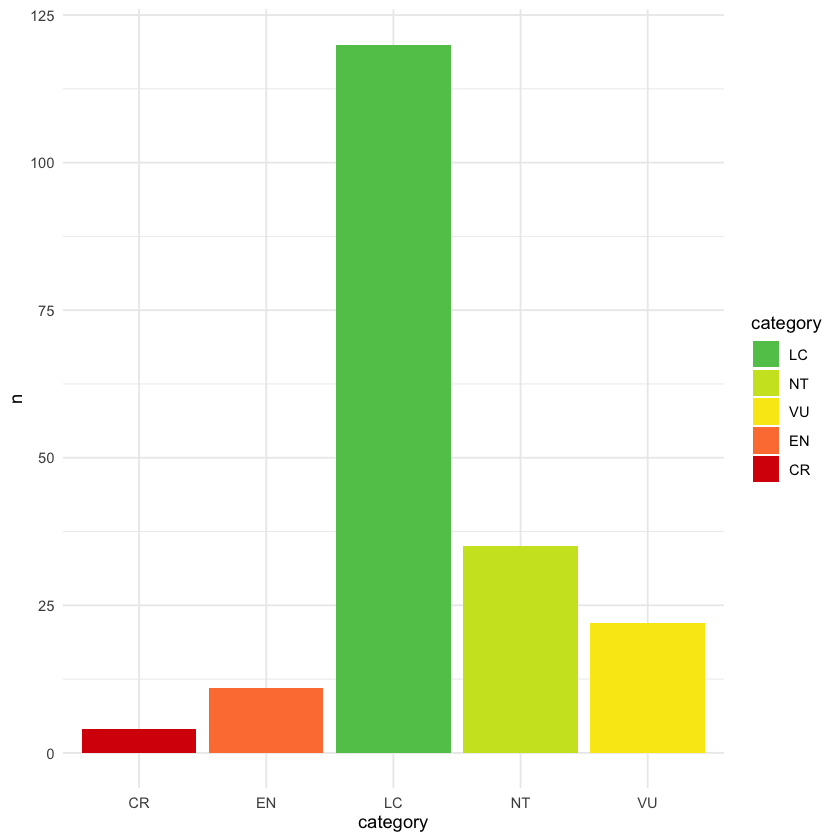

In [19]:
# IUCN color palette demo
df <- data.frame(
  category = c("LC", "NT", "VU", "EN", "CR"),
  n = c(120, 35, 22, 11, 4)
)

ggplot(df, aes(category, n, fill = category)) +
  geom_col() +
  scale_fill_iucn() +
  theme_minimal()


## 11) Teaching exercises

1. Replace the species list with your own region-specific taxa.
2. Pick one threat code and one action code; compare returned assessments.
3. Build a one-page summary with:
- top categories,
- most common trends,
- citation block from `rl_citation()`.

## 12) Troubleshooting

If you see errors:
- Confirm key exists: `Sys.getenv("IUCN_REDLIST_KEY")`
- Re-run: `init_rredlist()`
- Inspect result structure with `str()` before selecting fields.
- Keep request loops small to avoid API rate-limit issues.
- If you see `internal error 1 in R_decompress1 with libdeflate`, reinstall packages in a fresh R session and use a non-synced library path (avoid OneDrive-synced libraries).


## 13) Important distinction

- `rredlist`: API client for querying IUCN Red List data.
- `redlistr`: assessment support toolbox (different package and purpose).